# Master Flat Creation

This notebook creates a normalized master flat from five R-band dome-flat
exposures obtained with the Tek2K_3 CCD detector.

Each flat frame is:

1. Overscan corrected independently for the two CCD amplifiers.
2. Trimmed to the 2048 × 2048 science region.
3. Corrected using the previously generated master bias.
4. Normalized by its median level.
5. Combined with the other flat frames using the median.

The resulting master flat describes the relative pixel-to-pixel sensitivity
of the detector in the r band.

In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

from astropy.io import fits
from astropy.stats import sigma_clipped_stats

In [2]:
PROJECT_DIR = Path("..").resolve()

FLAT_DIR = PROJECT_DIR / "Flats"
PRODUCTS_DIR = PROJECT_DIR / "products"
FIGURES_DIR = PROJECT_DIR / "Figures"

flat_files = sorted(FLAT_DIR.glob("*.fits*"))

print("Flat frames found:", len(flat_files))

Flat frames found: 5


In [3]:
def get_image_hdu(filename):
    """Return the first HDU containing a 2D image."""

    with fits.open(filename) as hdul:
        for i, hdu in enumerate(hdul):
            if hdu.data is not None and hdu.data.ndim == 2:
                return i

    raise ValueError(f"No 2D image found in {filename}")

In [4]:
def overscan_correct_and_trim(data):
    """
    Perform row-by-row overscan correction for the two amplifiers
    and reconstruct the 2048 x 2048 detector image.
    """

    # Amplifier 1
    amp1 = data[:, 10:1034].astype(float)
    overscan1 = data[:, 1044:1084].astype(float)

    level1 = np.median(
        overscan1,
        axis=1,
        keepdims=True
    )

    amp1_corrected = amp1 - level1

    # Amplifier 2
    amp2 = data[:, 1134:2158].astype(float)
    overscan2 = data[:, 1084:1124].astype(float)

    level2 = np.median(
        overscan2,
        axis=1,
        keepdims=True
    )

    amp2_corrected = amp2 - level2

    return np.hstack([
        amp1_corrected,
        amp2_corrected
    ])

In [5]:
master_bias_path = PRODUCTS_DIR / "master_bias.fits"

with fits.open(master_bias_path) as hdul:
    master_bias = hdul[0].data.astype(float)

print("Master Bias shape:", master_bias.shape)
print("Master Bias median:", np.median(master_bias))

Master Bias shape: (2048, 2048)
Master Bias median: 2.5


In [6]:
test_flat_file = flat_files[0]

hdu_index = get_image_hdu(test_flat_file)

with fits.open(test_flat_file) as hdul:
    raw_flat = hdul[hdu_index].data.astype(float)
    flat_header = hdul[hdu_index].header

print("OBJECT:", flat_header.get("OBJECT"))
print("IMAGETYP:", flat_header.get("IMAGETYP"))
print("FILTER2:", flat_header.get("FILTER2"))
print("EXPTIME:", flat_header.get("EXPTIME"))
print("Shape:", raw_flat.shape)

OBJECT: R-dflat
IMAGETYP: dflat
FILTER2: r
EXPTIME: 120.0
Shape: (2048, 2168)


In [7]:
flat_trimmed = overscan_correct_and_trim(raw_flat)

print("Trimmed flat shape:", flat_trimmed.shape)

Trimmed flat shape: (2048, 2048)


In [8]:
flat_bias_corrected = flat_trimmed - master_bias

In [9]:
mean_flat, median_flat, std_flat = sigma_clipped_stats(
    flat_bias_corrected,
    sigma=3,
    maxiters=5
)

print(f"Mean   : {mean_flat:.2f} ADU")
print(f"Median : {median_flat:.2f} ADU")
print(f"Std    : {std_flat:.2f} ADU")

Mean   : 29876.58 ADU
Median : 29846.50 ADU
Std    : 702.80 ADU


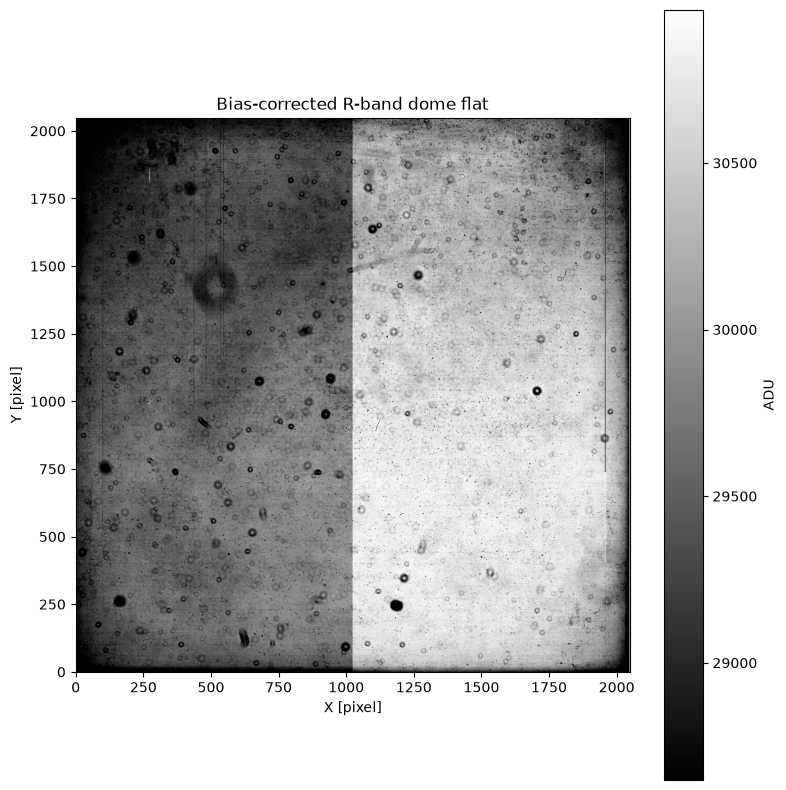

In [10]:
vmin, vmax = np.percentile(
    flat_bias_corrected,
    [5, 95]
)

plt.figure(figsize=(8, 8))

plt.imshow(
    flat_bias_corrected,
    origin="lower",
    cmap="gray",
    vmin=vmin,
    vmax=vmax
)

plt.colorbar(label="ADU")

plt.xlabel("X [pixel]")
plt.ylabel("Y [pixel]")
plt.title("Bias-corrected R-band dome flat")

plt.tight_layout()
plt.show()

In [11]:
flat_normalized = (
    flat_bias_corrected /
    median_flat
)

In [12]:
print(
    "Normalized median:",
    np.median(flat_normalized)
)

Normalized median: 0.9996481999564438


In [13]:
normalized_flats = []

for filename in flat_files:

    hdu_index = get_image_hdu(filename)

    with fits.open(filename) as hdul:
        data = hdul[hdu_index].data.astype(float)

    # Overscan + trim
    corrected = overscan_correct_and_trim(data)

    # Master-bias subtraction
    corrected -= master_bias

    # Robust median
    _, median_level, _ = sigma_clipped_stats(
        corrected,
        sigma=3,
        maxiters=5
    )

    # Normalize
    normalized = corrected / median_level

    normalized_flats.append(normalized)

normalized_flats = np.array(normalized_flats)

print(
    "Flat stack shape:",
    normalized_flats.shape
)

Flat stack shape: (5, 2048, 2048)


In [14]:
for i, flat in enumerate(normalized_flats, start=1):

    _, med, std = sigma_clipped_stats(
        flat,
        sigma=3,
        maxiters=5
    )

    print(
        f"Flat {i:02d}: "
        f"median={med:.5f}, "
        f"std={std:.5f}"
    )

Flat 01: median=1.00000, std=0.02355
Flat 02: median=1.00000, std=0.02354
Flat 03: median=1.00000, std=0.02351
Flat 04: median=1.00000, std=0.02354
Flat 05: median=1.00000, std=0.02351


In [15]:
master_flat = np.median(
    normalized_flats,
    axis=0
)

In [16]:
mean_mf, median_mf, std_mf = sigma_clipped_stats(
    master_flat,
    sigma=3,
    maxiters=5
)

print("=== Master Flat ===")
print(f"Mean   : {mean_mf:.5f}")
print(f"Median : {median_mf:.5f}")
print(f"Std    : {std_mf:.5f}")

print()
print("Minimum:", np.min(master_flat))
print("Maximum:", np.max(master_flat))

=== Master Flat ===
Mean   : 1.00103
Median : 0.99989
Std    : 0.02335

Minimum: -0.003615518788843542
Maximum: 2.071001482180152


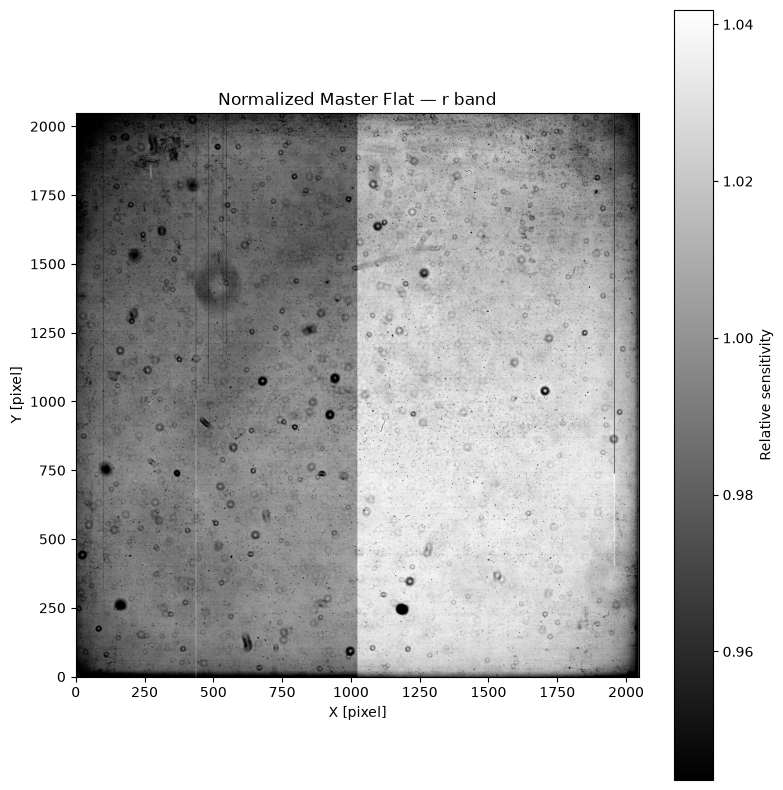

In [17]:
vmin, vmax = np.percentile(
    master_flat,
    [2, 98]
)

plt.figure(figsize=(8, 8))

plt.imshow(
    master_flat,
    origin="lower",
    cmap="gray",
    vmin=vmin,
    vmax=vmax
)

plt.colorbar(
    label="Relative sensitivity"
)

plt.xlabel("X [pixel]")
plt.ylabel("Y [pixel]")
plt.title("Normalized Master Flat — r band")

plt.tight_layout()
plt.show()

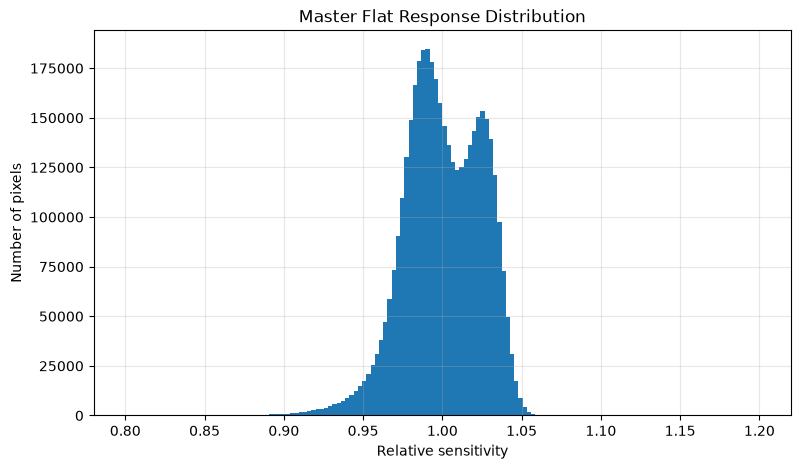

In [18]:
good = np.isfinite(master_flat)

plt.figure(figsize=(9, 5))

plt.hist(
    master_flat[good].ravel(),
    bins=150,
    range=(0.8, 1.2)
)

plt.xlabel("Relative sensitivity")
plt.ylabel("Number of pixels")
plt.title("Master Flat Response Distribution")

plt.grid(alpha=0.3)

plt.show()

In [19]:
flat_header_out = fits.Header()

flat_header_out["IMAGETYP"] = "MASTER_FLAT"
flat_header_out["FILTER"] = "r"
flat_header_out["NCOMBINE"] = len(flat_files)
flat_header_out["DETECTOR"] = "Tek2K_3"
flat_header_out["HISTORY"] = "Overscan corrected"
flat_header_out["HISTORY"] = "Master bias subtracted"
flat_header_out["HISTORY"] = "Individual flats normalized"
flat_header_out["HISTORY"] = "Combined using median"

master_flat_path = (
    PRODUCTS_DIR /
    "master_flat_r.fits"
)

fits.writeto(
    master_flat_path,
    master_flat.astype(np.float32),
    header=flat_header_out,
    overwrite=True
)

print("Saved:")
print(master_flat_path)

Saved:
C:\Users\rodri\NoirLab\products\master_flat_r.fits


In [20]:
percentiles = [
    0,
    0.01,
    0.1,
    1,
    5,
    50,
    95,
    99,
    99.9,
    99.99,
    100
]

values = np.percentile(master_flat, percentiles)

for p, value in zip(percentiles, values):
    print(f"{p:6.2f}% : {value:.6f}")

  0.00% : -0.003616
  0.01% : -0.000850
  0.10% : 0.000511
  1.00% : 0.927869
  5.00% : 0.960232
 50.00% : 0.999545
 95.00% : 1.036823
 99.00% : 1.045089
 99.90% : 1.460361
 99.99% : 2.024604
100.00% : 2.071001


In [21]:
low_pixels = master_flat < 0.5
high_pixels = master_flat > 1.5

n_low = np.sum(low_pixels)
n_high = np.sum(high_pixels)

total = master_flat.size

print(
    f"Pixels < 0.5: {n_low} "
    f"({100*n_low/total:.5f} %)"
)

print(
    f"Pixels > 1.5: {n_high} "
    f"({100*n_high/total:.5f} %)"
)

Pixels < 0.5: 10969 (0.26152 %)
Pixels > 1.5: 3197 (0.07622 %)


In [22]:
bad_flat = (
    ~np.isfinite(master_flat) |
    (master_flat < 0.5) |
    (master_flat > 1.5)
)

print("Bad pixels from flat:", np.sum(bad_flat))
print(
    "Percentage:",
    100 * np.sum(bad_flat) / master_flat.size
)

Bad pixels from flat: 14166
Percentage: 0.33774375915527344


In [23]:
bad_bias = (
    ~np.isfinite(master_bias) |
    (master_bias > 500) |
    (master_bias < -500)
)

In [24]:
bad_pixel_mask = bad_flat | bad_bias

print("Total bad pixels:", np.sum(bad_pixel_mask))
print(
    "Fraction:",
    100 * np.sum(bad_pixel_mask) / bad_pixel_mask.size,
    "%"
)

Total bad pixels: 14759
Fraction: 0.3518819808959961 %


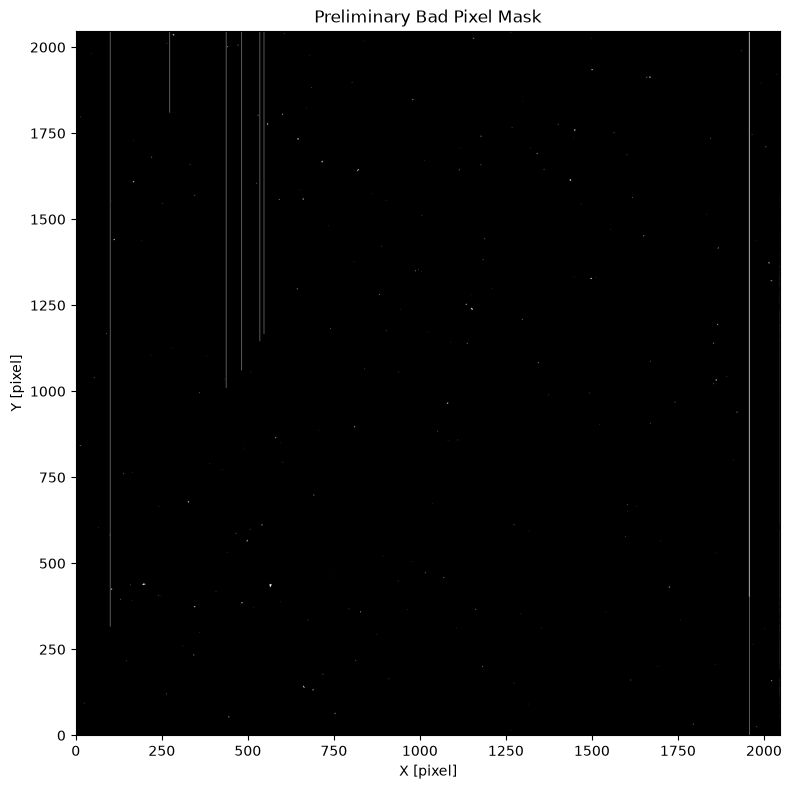

In [25]:
plt.figure(figsize=(8, 8))

plt.imshow(
    bad_pixel_mask,
    origin="lower",
    cmap="gray"
)

plt.xlabel("X [pixel]")
plt.ylabel("Y [pixel]")
plt.title("Preliminary Bad Pixel Mask")

plt.tight_layout()
plt.show()

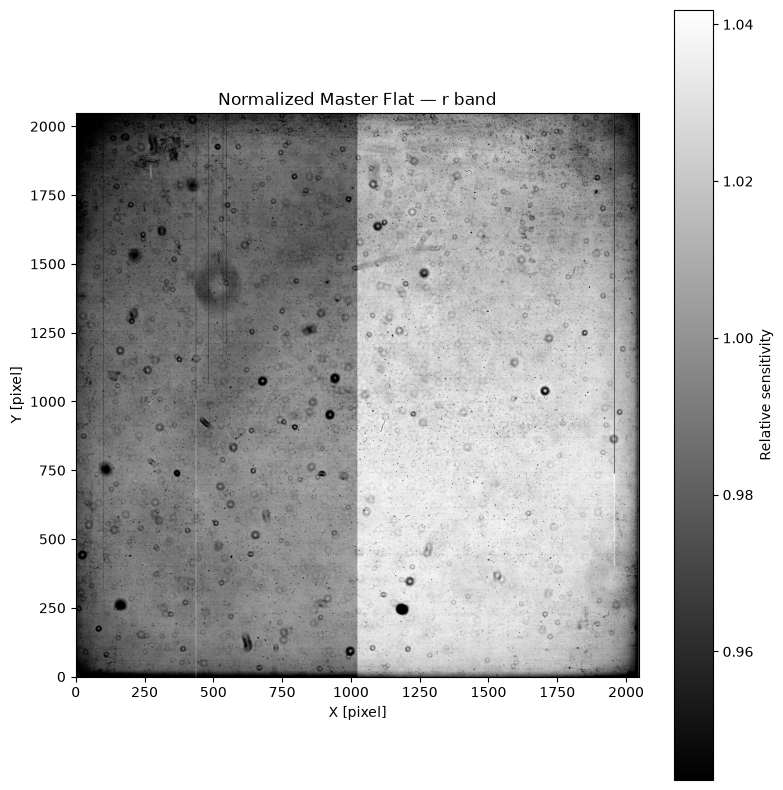

In [26]:
vmin, vmax = np.percentile(master_flat, [2, 98])

plt.figure(figsize=(8, 8))

plt.imshow(
    master_flat,
    origin="lower",
    cmap="gray",
    vmin=vmin,
    vmax=vmax
)

plt.colorbar(label="Relative sensitivity")

plt.xlabel("X [pixel]")
plt.ylabel("Y [pixel]")
plt.title("Normalized Master Flat — r band")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "master_flat_r.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()